In [ ]:
import pandas as pd
import numpy as np

# 1. Chargement des données
# On met juste le nom du fichier car ils sont à côté du script
print("Chargement des fichiers...")
tracks = pd.read_csv('tracks.tsv', sep='\t', low_memory=False, index_col='track_id')
echonest = pd.read_csv('echonest_features.tsv', sep='\t', index_col='track_id')
spectral = pd.read_csv('spectral_features.tsv', sep='\t', index_col='track_id')

# 2. Sélection des colonnes utiles dans 'tracks'
# On garde la cible (genre_top), la durée (duration) et l'artiste
tracks_subset = tracks[['genre_top', 'duration', 'artist_name']]

# 3. Fusion des datasets (Merge)
# On joint les features audio avec nos labels
full_data = tracks_subset.join([echonest, spectral], how='inner')

# 4. Nettoyage initial (Suppression des morceaux sans genre)
clean_data = full_data.dropna(subset=['genre_top'])

# 5. Nettoyage des noms de colonnes
clean_data.columns = clean_data.columns.str.strip().str.lower().str.replace(' ', '_')


print(f"Taille du dataset fusionné : {clean_data.shape}")
print("-" * 30)
display(clean_data.head())

Chargement des fichiers...
------------------------------
✅ Chargement réussi !
Taille du dataset fusionné : (6962, 32)
------------------------------


,genre_top,duration,artist_name,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,...,spectral_centroid_min_01,spectral_centroid_skew_01,spectral_centroid_std_01,spectral_rolloff_kurtosis_01,spectral_rolloff_max_01,spectral_rolloff_mean_01,spectral_rolloff_median_01,spectral_rolloff_min_01,spectral_rolloff_skew_01,spectral_rolloff_std_01
track_id,,,,,,,,,,,,,,,,,,,,,
11870,Hip-Hop,131,Wildahead Portibeast,0.373039,0.429892,0.645929,0.769285,0.195042,0.101240,159.908,...,327.569489,2.080017,575.112488,2.839292,8968.579102,2338.119629,1981.054688,516.796875,1.812383,1234.268433
11871,Hip-Hop,185,Wildahead Portibeast,0.908215,0.427918,0.694364,0.950413,0.269082,0.180927,188.077,...,187.277390,1.886271,655.114319,2.036670,9560.742188,2132.796143,1830.322266,226.098633,1.412759,1387.095459
11872,Hip-Hop,183,Wildahead Portibeast,0.204111,0.501329,0.608690,0.725811,0.125451,0.623711,137.676,...,99.604340,1.492531,645.915894,-0.463741,9345.410156,2760.100342,2583.984375,64.599609,0.245426,1420.888672
11873,Hip-Hop,213,Wildahead Portibeast,0.464478,0.419687,0.743163,0.786033,0.214622,0.142762,79.371,...,203.401001,0.916191,615.655090,-0.114326,9722.241211,2445.449219,2271.752930,86.132812,0.581035,1330.056030
11874,Hip-Hop,162,Wildahead Portibeast,0.921960,0.350383,0.588584,0.861204,0.120561,0.187306,190.518,...,244.832825,2.521557,755.226440,4.567743,10142.138672,2265.638672,1905.688477,215.332031,1.849876,1474.148682


In [9]:
# 1. Vérification des doublons
doublons = clean_data.duplicated().sum()
print(f"Nombre de lignes dupliquées : {doublons}")

# 2. Vérification des valeurs manquantes (NaN) par colonne
# On affiche seulement les colonnes qui ont des problèmes
missing = clean_data.isnull().sum()
print("\nColonnes avec valeurs manquantes :")
print(missing[missing > 0])

Nombre de lignes dupliquées : 0

Colonnes avec valeurs manquantes :
danceability    15
speechiness     93
valence         17
dtype: int64


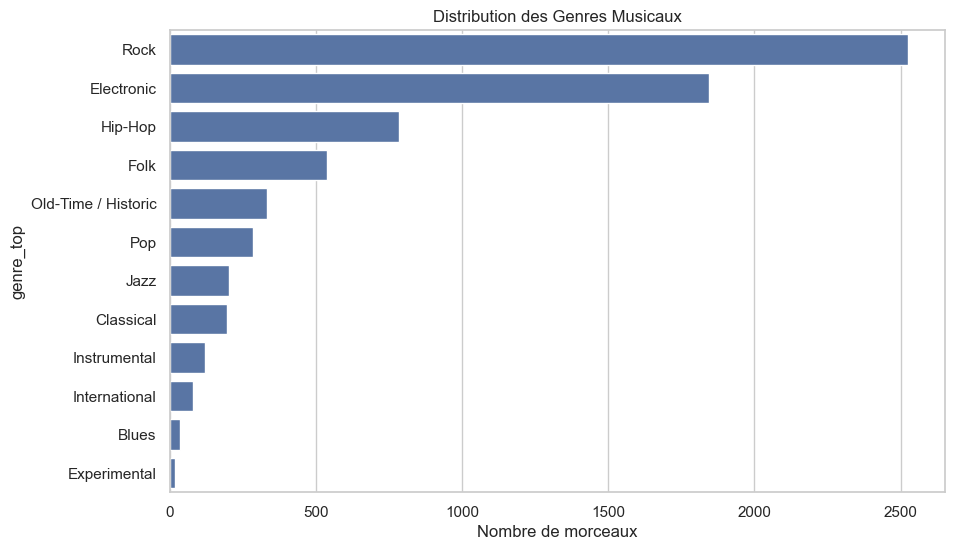

Nombre de morceaux par genre :
genre_top
Rock                   2525
Electronic             1844
Hip-Hop                 784
Folk                    539
Old-Time / Historic     332
Pop                     283
Jazz                    204
Classical               195
Instrumental            121
International            81
Blues                    36
Experimental             18
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# Création du graphique en barres
sns.countplot(y='genre_top', data=clean_data, order=clean_data['genre_top'].value_counts().index)
plt.title("Distribution des Genres Musicaux")
plt.xlabel("Nombre de morceaux")
plt.show()

# Affichage des chiffres exacts
print("Nombre de morceaux par genre :")
print(clean_data['genre_top'].value_counts())

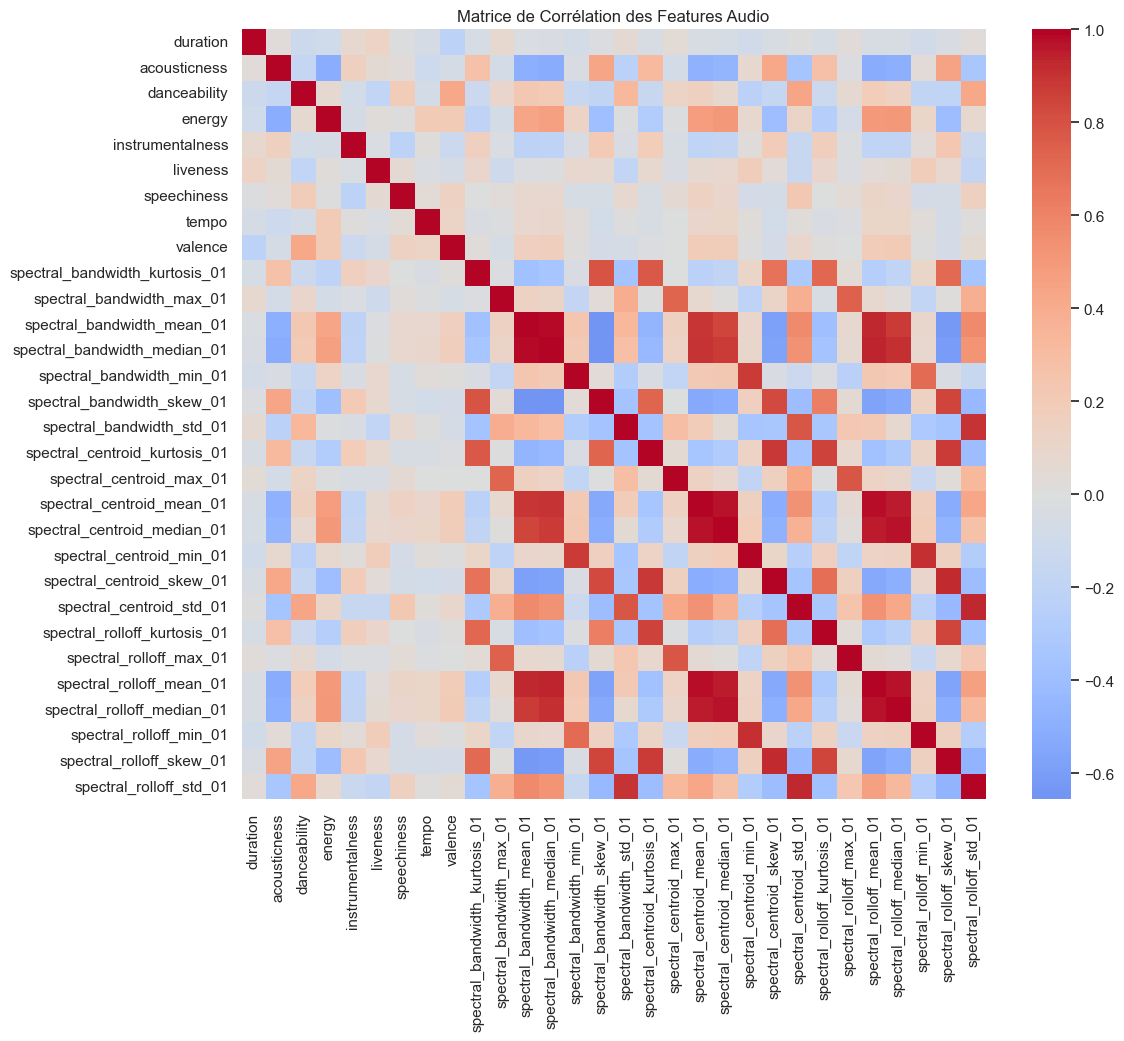

Top 5 des features les plus liées à la durée (duration) :
duration        1.000000
valence         0.218261
liveness        0.130306
danceability    0.120266
energy          0.094418
Name: duration, dtype: float64


In [11]:
# On sélectionne uniquement les colonnes numériques pour le calcul
numeric_data = clean_data.select_dtypes(include=['float64', 'int64'])

# Calcul de la matrice de corrélation
corr_matrix = numeric_data.corr()

# Affichage de la Heatmap (Carte de chaleur)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Matrice de Corrélation des Features Audio")
plt.show()

# Zoom sur ce qui influence la durée du morceau
print("Top 5 des features les plus liées à la durée (duration) :")
print(corr_matrix['duration'].abs().sort_values(ascending=False).head(5))

Tracks: (99995, 13)
Echonest: (11440, 8)
Taille après fusion Tracks + Echonest et nettoyage genre: (6962, 11)
Corrélations avec le Genre (encodé) :
energy              0.103778
tempo               0.059014
liveness            0.057502
acousticness        0.046771
valence            -0.008289
instrumentalness   -0.077963
speechiness        -0.131980
danceability       -0.337164
Name: genre_code, dtype: float64

Mapping des Genres :
0: Blues
1: Classical
2: Electronic
3: Experimental
4: Folk
5: Hip-Hop
6: Instrumental
7: International
8: Jazz
9: Old-Time / Historic
10: Pop
11: Rock


C:\Users\Matthieu\AppData\Local\Temp\ipykernel_15288\930191875.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_corr.values, y=genre_corr.index, palette='coolwarm')


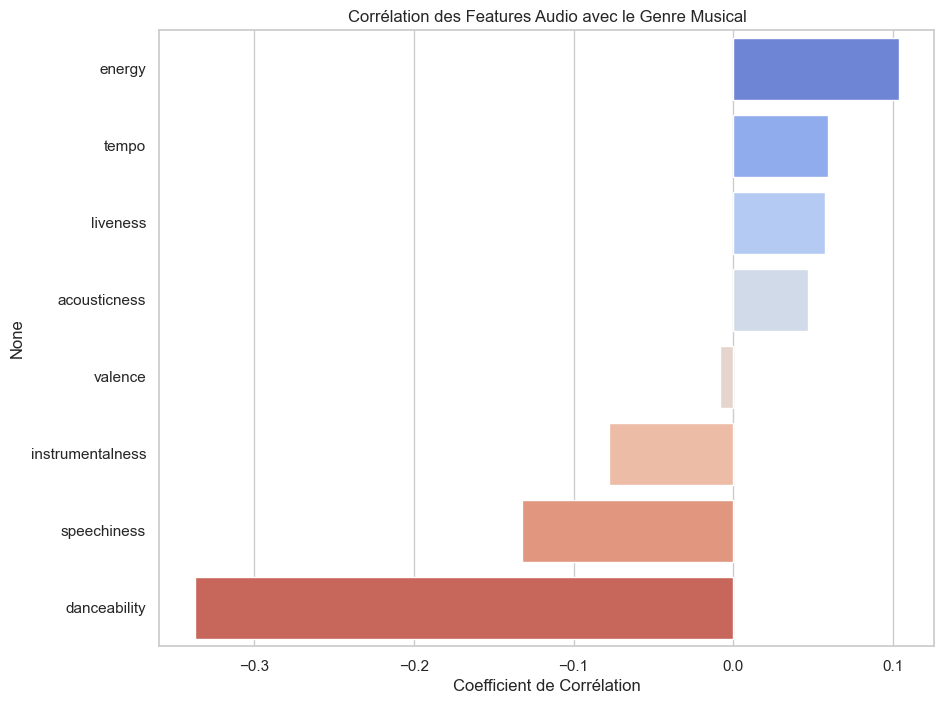

In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Chargement
tracks = pd.read_csv('tracks.tsv', sep='\t', low_memory=False, index_col='track_id')
echonest = pd.read_csv('echonest_features.tsv', sep='\t', index_col='track_id')

# Vérification des tailles avant fusion
print(f"Tracks: {tracks.shape}")
print(f"Echonest: {echonest.shape}")

# Fusion Tracks + Echonest (On garde spectral de côté pour l'instant pour voir si on gagne des lignes)
# On ne garde que les colonnes nécessaires
tracks_subset = tracks[['genre_top', 'title', 'artist_name']]
data = tracks_subset.join(echonest, how='inner')

# Nettoyage
data = data.dropna(subset=['genre_top'])
print(f"Taille après fusion Tracks + Echonest et nettoyage genre: {data.shape}")

# Encodage du genre pour la corrélation
le = LabelEncoder()
data['genre_code'] = le.fit_transform(data['genre_top'])

# Calcul des corrélations
# On ne garde que les colonnes numériques (features audio + genre_code)
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = data[numeric_cols].corr()

# Focus sur le genre
genre_corr = corr_matrix['genre_code'].drop('genre_code').sort_values(ascending=False)

print("Corrélations avec le Genre (encodé) :")
print(genre_corr)

# Visualisation
plt.figure(figsize=(10, 8))
sns.barplot(x=genre_corr.values, y=genre_corr.index, palette='coolwarm')
plt.title('Corrélation des Features Audio avec le Genre Musical')
plt.xlabel('Coefficient de Corrélation')


# Affichage des genres pour comprendre l'encodage
print("\nMapping des Genres :")
for i, genre in enumerate(le.classes_):
    print(f"{i}: {genre}")